# 3-Parameter MCMC: $H_0$, $\Omega_m$, $\Omega_r$

Flat universe assumed ($\Omega_k = 0$), so the dark-energy density is **not** a free
parameter — it is fixed by the flatness condition:

$$\Omega_\Lambda = 1 - \Omega_m - \Omega_r$$

Free parameters sampled by MCMC: $\Omega_m$, $H_0$, and $\Omega_r$ (radiation).

In [2]:
import numpy as np
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

In [3]:
import os

# every sampler cell below checks this directory for a saved chain first and
# loads it instead of re-running - restarting the kernel no longer means
# re-sampling for 50k+ iterations just to tweak a plot downstream.
# Delete the relevant .csv/.pkl/.h5 file here (or flip force_rerun=True in a
# sampler cell) if you actually want to redo a run from scratch.
cache_dir = "mcmc_cache_3param"
os.makedirs(cache_dir, exist_ok=True)

In [4]:
# fiducial parameters (starting point / sanity-check values, not fixed priors)
h = 0.71
Omega_m = 0.3
Omega_r = 9.2e-5      # ~ photon + neutrino density today
Omega_Lambda = 1 - Omega_m - Omega_r   # flatness

H0 = 100 * h            # km/s/Mpc
c = 299792.458          # speed of light, km/s

## Distances in a Flat, Radiation + Matter + $\Lambda$ Universe

$$H(z) = H_0\sqrt{\Omega_m (1+z)^3 + \Omega_r (1+z)^4 + \Omega_\Lambda}, \qquad \Omega_\Lambda = 1-\Omega_m-\Omega_r$$

Flat geometry means the transverse comoving distance equals the comoving distance directly
(no sinh/sin curvature correction needed).

In [5]:
# Hubble parameter with a radiation term; Omega_Lambda fixed by flatness
def hubble_param(z, H0_val, omega_m_val, omega_r_val):
    omega_lambda_val = 1 - omega_m_val - omega_r_val
    return H0_val * np.sqrt(omega_m_val * (1 + z)**3 + omega_r_val * (1 + z)**4 + omega_lambda_val)

def comoving_integrand(z, H0_val, omega_m_val, omega_r_val):
    return c / hubble_param(z, H0_val, omega_m_val, omega_r_val)

def comoving_distance_3p(z, H0_val, omega_m_val, omega_r_val):
    D_c, err = integrate.quad(comoving_integrand, 0, z, args=(H0_val, omega_m_val, omega_r_val))
    return D_c

def luminosity_distance_3p(z, H0_val, omega_m_val, omega_r_val):
    D_c = comoving_distance_3p(z, H0_val, omega_m_val, omega_r_val)
    return D_c * (1 + z)

def distance_modulus_3p(z, H0_val, omega_m_val, omega_r_val):
    D_L = luminosity_distance_3p(z, H0_val, omega_m_val, omega_r_val)
    return 5 * np.log10(D_L) + 25

In [6]:
# sanity check at a single redshift, fiducial parameters
z_test = 2
D_L_test = luminosity_distance_3p(z_test, H0, Omega_m, Omega_r)
mu_test = distance_modulus_3p(z_test, H0, Omega_m, Omega_r)

print(f"Omega_Lambda (fiducial, from flatness): {1 - Omega_m - Omega_r:.6f}")
print(f"Luminosity distance at z={z_test}: {D_L_test:.3f} Mpc")
print(f"Distance modulus at z={z_test}: {mu_test:.3f}")

Omega_Lambda (fiducial, from flatness): 0.699908
Luminosity distance at z=2: 15318.007 Mpc
Distance modulus at z=2: 45.926


## Pantheon Supernova Data

Same dataset and columns as `cosmic_distnaces.ipynb` (`#name`, `zcmb`, `zhel`, `dz`, `mb`, `dmb`, `dist_mod`).

In [7]:
sn_data_path = "../Pantheon_SNdata.csv"
raw_excel_path = "../Pantheon - Scolnic SNe 1A 1048 z-asc 27May'19 (2).xlsx"

try:
    sn_df = pd.read_csv(sn_data_path)
    if 'dist_mod' not in sn_df.columns:
        sn_df['dist_mod'] = sn_df['mb'] + 19.35
        sn_df.to_csv(sn_data_path, index=False)
except FileNotFoundError:
    sn_df = pd.read_excel(raw_excel_path)
    sn_df.columns = sn_df.iloc[0]
    sn_df = sn_df[1:].reset_index(drop=True)
    sn_df['dist_mod'] = sn_df['mb'] + 19.35
    sn_df.to_csv(sn_data_path, index=False)

sn_df.head()

,#name,zcmb,zhel,dz,mb,dmb,dist_mod
0,2002cr,0.01012,0.01012,0,13.90745,0.19825,33.25745
1,2002dp,0.01038,0.01038,0,14.04960,0.20480,33.39960
2,2009an,0.01043,0.01043,0,13.92480,0.20035,33.27480
3,2006bh,0.01082,0.01082,0,14.00860,0.18445,33.35860
4,1998dk,0.01209,0.01209,0,13.97910,0.19140,33.32910


## Likelihood Setup (shared by both samplers)

In [8]:
def chi_squared(observed, theoretical, error):
    observed = np.array(observed)
    theoretical = np.array(theoretical)
    error = np.array(error)
    return np.sum(((observed - theoretical) / error) ** 2)

def chi_squared_3p(H0_val, omega_m_val, omega_r_val):
    mu_model = [distance_modulus_3p(z, H0_val, omega_m_val, omega_r_val) for z in sn_df['zcmb']]
    return chi_squared(sn_df['dist_mod'], mu_model, sn_df['dmb'])

In [9]:
# fiducial chi-squared check
chi_sq_fiducial = chi_squared_3p(H0, Omega_m, Omega_r)
print(f"Chi-squared @ H0={H0}, Omega_m={Omega_m}, Omega_r={Omega_r}: {chi_sq_fiducial:.3f}")

Chi-squared @ H0=71.0, Omega_m=0.3, Omega_r=9.2e-05: 1098.120


## Prior Bounds

Free parameter order: $\theta = (\Omega_m, H_0, \Omega_r)$.

$\Omega_r$'s fiducial value today is tiny ($\sim 9\times10^{-5}$), so its prior range is set
much narrower than $\Omega_m$'s — wide enough (0 to 1e-2, i.e. ~100x the fiducial value) to let
the data actually move it, but not so wide it wastes sampler time in clearly unphysical territory.

In [10]:
# theta = (omega_m, H0, omega_r)
param_bounds = {
    'omega_m': [0.05, 0.6],
    'H0': [55, 85],
    'omega_r': [0.0, 1e-2],
}

def in_bounds(theta):
    omega_m_val, H0_val, omega_r_val = theta
    return (param_bounds['omega_m'][0] <= omega_m_val <= param_bounds['omega_m'][1] and
            param_bounds['H0'][0] <= H0_val <= param_bounds['H0'][1] and
            param_bounds['omega_r'][0] <= omega_r_val <= param_bounds['omega_r'][1])

def log_prior_3p(theta):
    return 0.0 if in_bounds(theta) else -np.inf

def log_likelihood_3p(theta):
    omega_m_val, H0_val, omega_r_val = theta
    return -0.5 * chi_squared_3p(H0_val, omega_m_val, omega_r_val)

def log_posterior_3p(theta):
    lp = log_prior_3p(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_3p(theta)

# Parameter Estimation: Metropolis-Hastings MCMC

Random-walk proposal over all three parameters simultaneously, accept/reject via the MH
chi-squared ratio (same acceptance rule used in the 2-parameter notebook).

In [11]:
# propose a new (omega_m, H0, omega_r) point via a Gaussian random walk, rejecting steps outside the prior box
def propose_step_3p(theta_prev, steps):
    theta_new = np.array(theta_prev) + np.array(steps) * np.random.normal(0, 1, size=3)
    if in_bounds(theta_new):
        return theta_new
    return propose_step_3p(theta_prev, steps)

In [12]:
# MH sampler settings: (omega_m, H0, omega_r) step sizes
mh_steps = np.array([0.005, 0.2, 2e-4])
mh_n_iterations = 50000  # 100000

print(f'Bounds: {param_bounds}')
print(f'Step sizes (omega_m, H0, omega_r): {mh_steps}')
print(f'Iterations: {mh_n_iterations}')

Bounds: {'omega_m': [0.05, 0.6], 'H0': [55, 85], 'omega_r': [0.0, 0.01]}
Step sizes (omega_m, H0, omega_r): [0.005  0.2    0.0002]
Iterations: 50000


In [13]:
# run the Metropolis-Hastings chain (or load a cached one)
import json

mh_cache_path = os.path.join(cache_dir, "mh_chain.csv")
mh_meta_path = os.path.join(cache_dir, "mh_meta.json")
force_rerun = False   # set True to ignore the cache and re-sample

mh_current_settings = {
    'n_iterations': mh_n_iterations,
    'steps': mh_steps.tolist(),
    'bounds': param_bounds,
}

mh_cache_valid = False
if os.path.exists(mh_cache_path) and os.path.exists(mh_meta_path) and not force_rerun:
    with open(mh_meta_path) as f:
        mh_cached_settings = json.load(f)
    mh_cache_valid = (mh_cached_settings == mh_current_settings)
    if not mh_cache_valid:
        print(f"Cache found but settings changed - re-running.")
        print(f"  cached:  {mh_cached_settings}")
        print(f"  current: {mh_current_settings}")

if mh_cache_valid:
    mh_chain = pd.read_csv(mh_cache_path)
    n_accepted = len(mh_chain)   # only accepted steps get appended, so this is exact
    print(f"Loaded cached MH chain from {mh_cache_path} ({len(mh_chain)} accepted samples)")

else:
    mh_chain = pd.DataFrame(columns=['Omega_m', 'H0', 'Omega_r', 'Chi_sq', 'Type'])

    theta_curr = np.array([
        np.random.uniform(*param_bounds['omega_m']),
        np.random.uniform(*param_bounds['H0']),
        np.random.uniform(*param_bounds['omega_r']),
    ])
    chi2_curr = chi_squared_3p(theta_curr[1], theta_curr[0], theta_curr[2])
    print("Starting point (omega_m, H0, omega_r):", theta_curr)
    print("Starting chi-squared:", chi2_curr, '\n')

    n_accepted = 0
    for n in range(mh_n_iterations):
        theta_prop = propose_step_3p(theta_curr, mh_steps)
        chi2_prop = chi_squared_3p(theta_prop[1], theta_prop[0], theta_prop[2])

        if chi2_prop <= chi2_curr:
            theta_curr, chi2_curr = theta_prop, chi2_prop
            mh_chain.loc[len(mh_chain)] = [*theta_curr, chi2_curr, 1]
            n_accepted += 1
        else:
            accept_prob = np.exp(-(chi2_prop - chi2_curr) / 2)
            if accept_prob > np.random.uniform(0, 1):
                theta_curr, chi2_curr = theta_prop, chi2_prop
                mh_chain.loc[len(mh_chain)] = [*theta_curr, chi2_curr, 2]
                n_accepted += 1

    print("Final (omega_m, H0, omega_r):", theta_curr)
    print("Final chi-squared:", chi2_curr)
    print(f"Acceptance fraction: {n_accepted / mh_n_iterations:.3f}")

    mh_chain.to_csv(mh_cache_path, index=False)
    with open(mh_meta_path, "w") as f:
        json.dump(mh_current_settings, f)
    print(f"Saved MH chain to {mh_cache_path}")

Loaded cached MH chain from mcmc_cache_3param\mh_chain.csv (27162 accepted samples)


In [14]:
# trim burn-in: keep from the first sample within 10% of the final chi-squared
final_chi2 = mh_chain['Chi_sq'].iloc[-1]
burn_in_idx = mh_chain[mh_chain['Chi_sq'] < 1.1 * final_chi2].index[0]
mh_chain_trimmed = mh_chain.iloc[burn_in_idx:].reset_index(drop=True)

print(f"Burn-in cutoff index: {burn_in_idx}")
print(f"Samples retained: {len(mh_chain_trimmed)} / {len(mh_chain)}")
mh_chain_trimmed.head()

Burn-in cutoff index: 40
Samples retained: 27122 / 27162


,Omega_m,H0,Omega_r,Chi_sq,Type
0,0.310745,70.932944,0.007400,1135.558956,1.0
1,0.314517,70.409011,0.007352,1082.578499,1.0
2,0.322020,70.251262,0.007143,1081.030359,1.0
3,0.318084,70.282062,0.007326,1077.577472,1.0
4,0.314551,70.272551,0.007333,1071.373220,1.0


<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_10892\3408341742.py:3: SyntaxWarning: invalid escape sequence '\O'
  mh_labels = ['$\Omega_m$', '$H_0$', '$\Omega_r$']
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_10892\3408341742.py:3: SyntaxWarning: invalid escape sequence '\O'
  mh_labels = ['$\Omega_m$', '$H_0$', '$\Omega_r$']


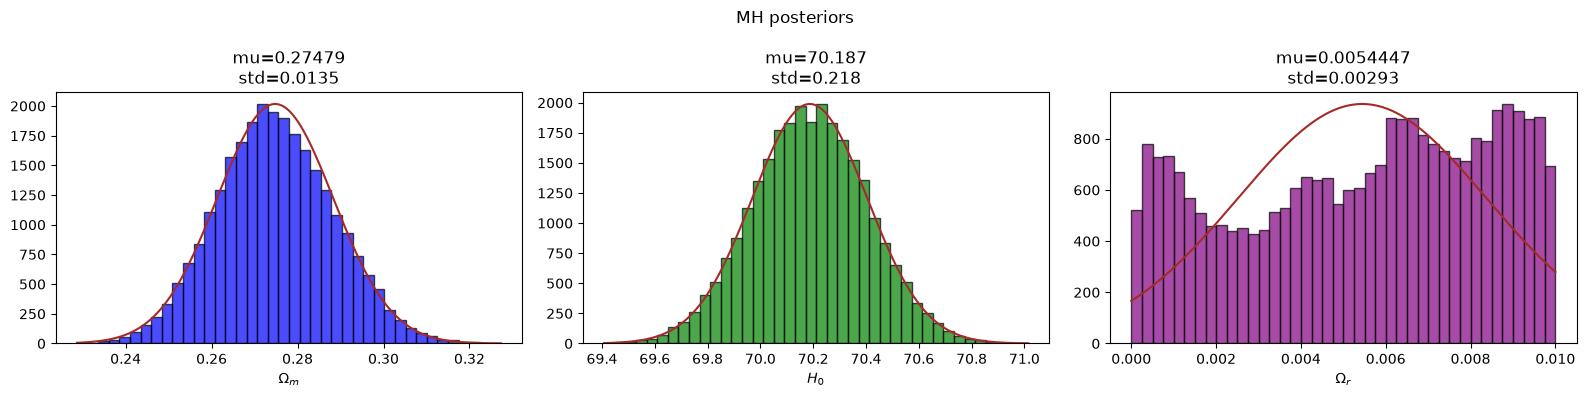

{'Omega_m': (np.float64(0.2747917801305528), np.float64(0.013519417969190437)), 'H0': (np.float64(70.18699679479094), np.float64(0.21812017501162562)), 'Omega_r': (np.float64(0.005444702789535439), np.float64(0.0029297780541593828))}


In [15]:
# posterior histograms with Gaussian fits, all three parameters
mh_params = ['Omega_m', 'H0', 'Omega_r']
mh_labels = ['$\Omega_m$', '$H_0$', '$\Omega_r$']
mh_colors = ['blue', 'green', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
mh_fit_results = {}

for ax, pname, label, color in zip(axes, mh_params, mh_labels, mh_colors):
    samples = mh_chain_trimmed[pname]
    mu, std = norm.fit(samples)
    mh_fit_results[pname] = (mu, std)

    counts, bins, _ = ax.hist(samples, bins=40, color=color, edgecolor='black', alpha=0.7)
    x = np.linspace(samples.min(), samples.max(), 1000)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p * counts.max() / p.max(), c='brown', linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_title(f'mu={mu:.5g}\nstd={std:.3g}')

plt.suptitle('MH posteriors')
plt.tight_layout()
plt.show()
print(mh_fit_results)

<>:6: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:6: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_10892\956181376.py:6: SyntaxWarning: invalid escape sequence '\O'
  axes[0].set_xlabel('$H_0$'); axes[0].set_ylabel('$\Omega_m$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_10892\956181376.py:7: SyntaxWarning: invalid escape sequence '\O'
  axes[0].set_title('MH: $H_0$ vs $\Omega_m$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_10892\956181376.py:12: SyntaxWarning: invalid escape sequence '\O'
  axes[1].set_xlabel('$\Omega_m$'); axes[1].set_y

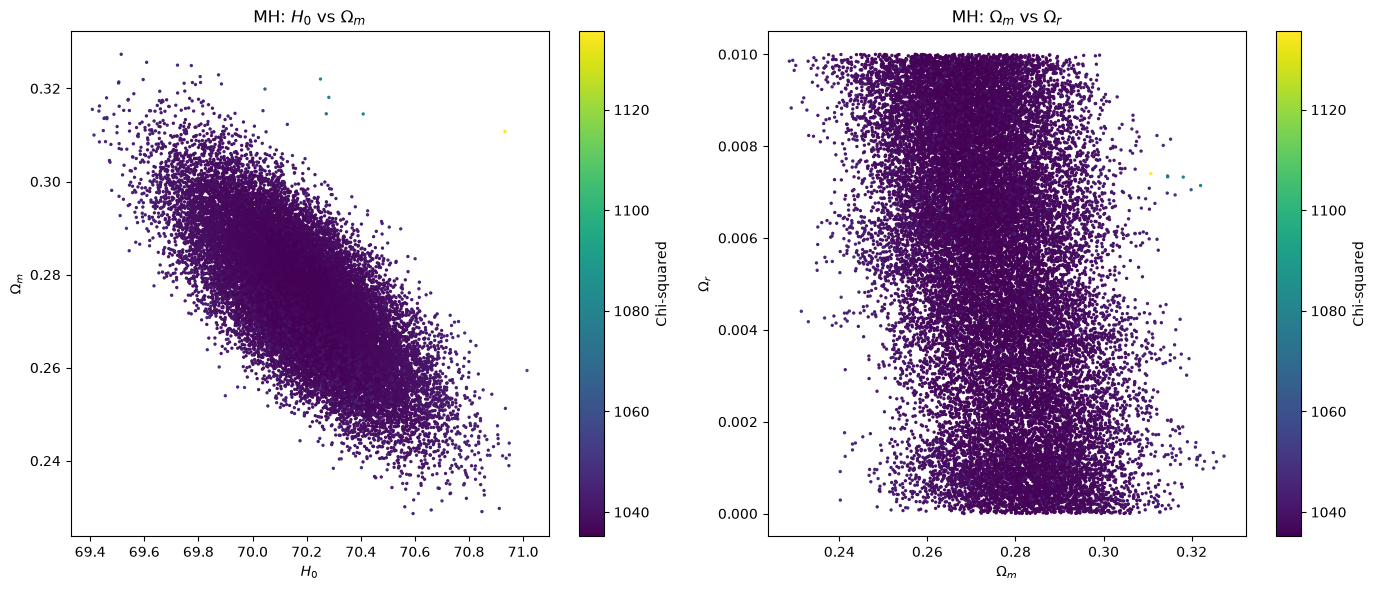

In [16]:
# pairwise sampling pathways colored by chi-squared
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(mh_chain_trimmed['H0'], mh_chain_trimmed['Omega_m'],
                       c=mh_chain_trimmed['Chi_sq'], cmap='viridis', s=2)
axes[0].set_xlabel('$H_0$'); axes[0].set_ylabel('$\Omega_m$')
axes[0].set_title('MH: $H_0$ vs $\Omega_m$')
plt.colorbar(sc0, ax=axes[0], label='Chi-squared')

sc1 = axes[1].scatter(mh_chain_trimmed['Omega_m'], mh_chain_trimmed['Omega_r'],
                       c=mh_chain_trimmed['Chi_sq'], cmap='viridis', s=2)
axes[1].set_xlabel('$\Omega_m$'); axes[1].set_ylabel('$\Omega_r$')
axes[1].set_title('MH: $\Omega_m$ vs $\Omega_r$')
plt.colorbar(sc1, ax=axes[1], label='Chi-squared')

plt.tight_layout()
plt.show()

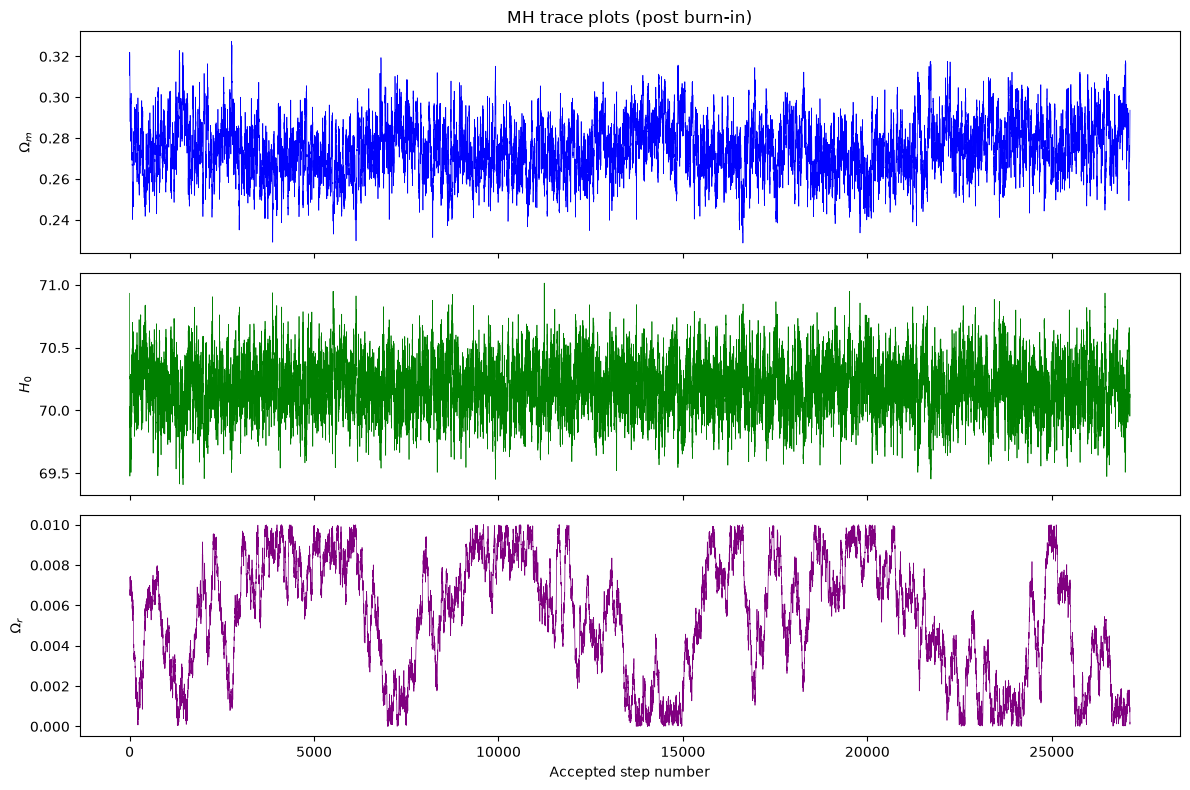

In [17]:
# trace plots for all three parameters
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, pname, label, color in zip(axes, mh_params, mh_labels, mh_colors):
    ax.plot(mh_chain_trimmed[pname], linewidth=0.5, color=color)
    ax.set_ylabel(label)
axes[0].set_title('MH trace plots (post burn-in)')
axes[-1].set_xlabel('Accepted step number')
plt.tight_layout()
plt.show()

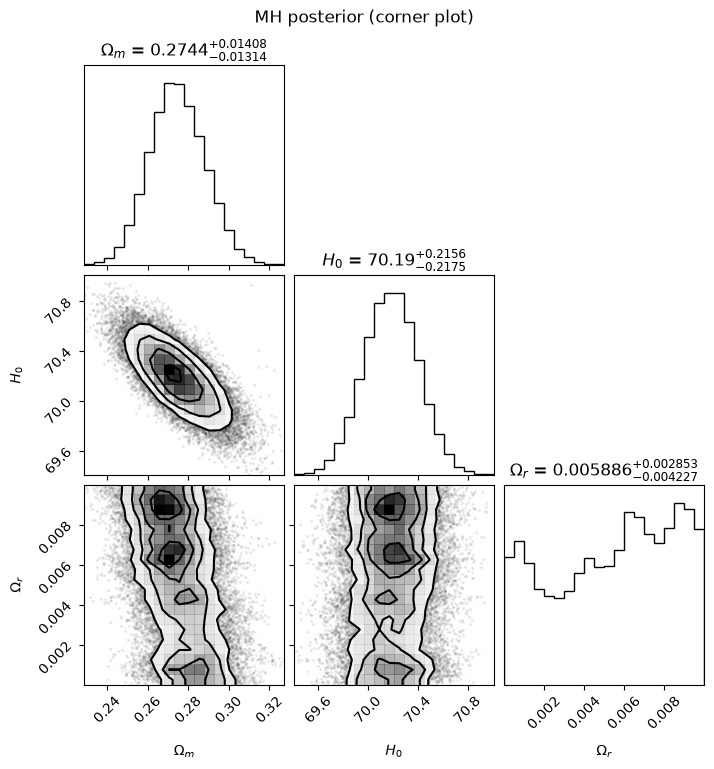

In [18]:
# corner plot: all pairwise posteriors + 1D marginals in one figure (MH)
import corner

mh_corner_samples = mh_chain_trimmed[['Omega_m', 'H0', 'Omega_r']].to_numpy()
corner.corner(mh_corner_samples, labels=['$\\Omega_m$', '$H_0$', '$\\Omega_r$'],
              show_titles=True, title_fmt='.4g')
plt.suptitle('MH posterior (corner plot)', y=1.02)
plt.show()

# Parameter Estimation: emcee Affine-Invariant Ensemble Sampler

Same `log_posterior_3p` likelihood, sampled with `emcee`. Requires `pip install emcee`.

In [20]:
import emcee
import time
import json

n_dim = 3
n_walkers = 15
n_steps = 3300
n_burn = 300

emcee_backend_path = os.path.join(cache_dir, "emcee_chain.h5")   # requires: pip install h5py
emcee_meta_path = os.path.join(cache_dir, "emcee_meta.json")
force_rerun_emcee = False   # set True to ignore the cache and re-sample

emcee_current_settings = {'n_walkers': n_walkers, 'n_steps': n_steps, 'n_dim': n_dim}

emcee_cache_valid = False
if os.path.exists(emcee_backend_path) and os.path.exists(emcee_meta_path) and not force_rerun_emcee:
    with open(emcee_meta_path) as f:
        emcee_cached_settings = json.load(f)
    emcee_cache_valid = (emcee_cached_settings == emcee_current_settings)
    if not emcee_cache_valid:
        print(f"Cache found but settings changed - re-running.")
        print(f"  cached:  {emcee_cached_settings}")
        print(f"  current: {emcee_current_settings}")

backend = emcee.backends.HDFBackend(emcee_backend_path)

if emcee_cache_valid:
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior_3p, backend=backend)
    print(f"Loaded cached emcee chain from {emcee_backend_path} ({backend.iteration} steps)")

else:
    theta0 = np.array([0.3, 70.0, 9.2e-5])   # (omega_m, H0, omega_r) initial guess
    spread = np.array([0.01, 0.5, 2e-5])
    initial_pos = theta0 + spread * np.random.randn(n_walkers, n_dim)
    initial_pos[:, 2] = np.clip(initial_pos[:, 2], param_bounds['omega_r'][0], param_bounds['omega_r'][1])

    backend.reset(n_walkers, n_dim)
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior_3p, backend=backend)

    start_time = time.time()
    sampler.run_mcmc(initial_pos, n_steps, progress=True)
    emcee_runtime = time.time() - start_time
    print(f"emcee runtime: {emcee_runtime:.2f} s")

    with open(emcee_meta_path, "w") as f:
        json.dump(emcee_current_settings, f)
    print(f"Saved emcee chain to {emcee_backend_path}")

print(f"Mean acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}")

100%|██████████| 3300/3300 [16:20<00:00,  3.37it/s]

emcee runtime: 981.01 s
Saved emcee chain to mcmc_cache_3param\emcee_chain.h5
Mean acceptance fraction: 0.596


In [21]:
# discard burn-in and flatten walkers into a single sample set
emcee_flat_samples = sampler.get_chain(discard=n_burn, flat=True)
emcee_logpost = sampler.get_log_prob(discard=n_burn, flat=True)

emcee_tau = sampler.get_autocorr_time(quiet=True)
print(f"Autocorrelation time (omega_m, H0, omega_r): {emcee_tau}")
print(f"Effective independent samples: {len(emcee_flat_samples) / np.mean(emcee_tau):.0f}")

Autocorrelation time (omega_m, H0, omega_r): [40.12120713 37.55309236 65.12058284]
Effective independent samples: 945


<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_10892\3109351170.py:2: SyntaxWarning: invalid escape sequence '\O'
  emcee_labels = ['$\Omega_m$', '$H_0$', '$\Omega_r$']
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_10892\3109351170.py:2: SyntaxWarning: invalid escape sequence '\O'
  emcee_labels = ['$\Omega_m$', '$H_0$', '$\Omega_r$']


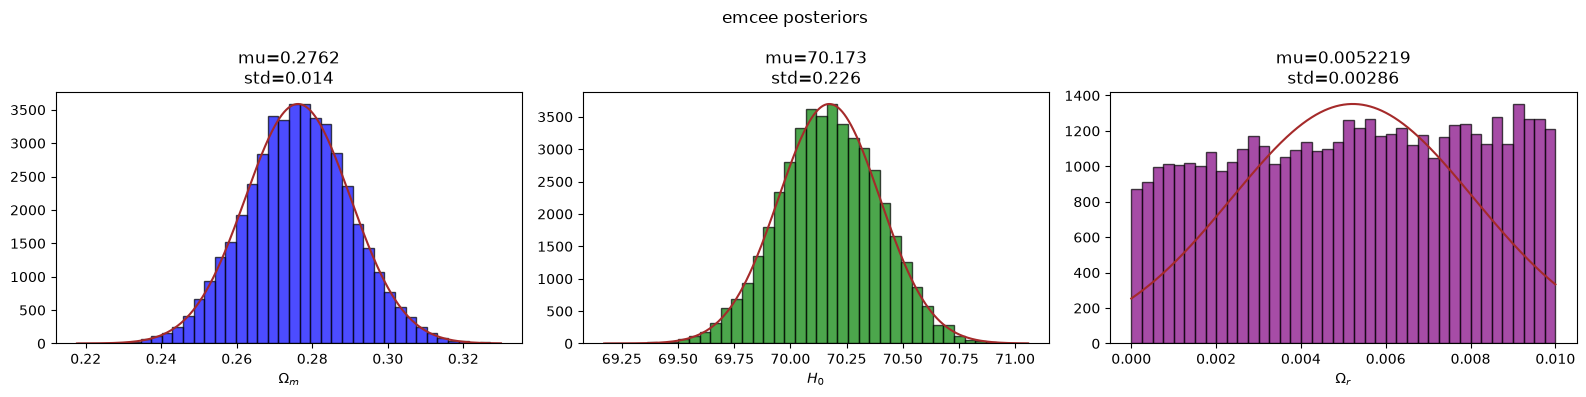

{'$\\Omega_m$': (np.float64(0.27619717740783223), np.float64(0.013961331373997517)), '$H_0$': (np.float64(70.17280019876227), np.float64(0.22585105019512627)), '$\\Omega_r$': (np.float64(0.005221941395490325), np.float64(0.002855773589139706))}


In [22]:
# posterior histograms with Gaussian fits, all three parameters
emcee_labels = ['$\Omega_m$', '$H_0$', '$\Omega_r$']
emcee_colors = ['blue', 'green', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
emcee_fit_results = {}

for i, (ax, label, color) in enumerate(zip(axes, emcee_labels, emcee_colors)):
    samples = emcee_flat_samples[:, i]
    mu, std = norm.fit(samples)
    emcee_fit_results[label] = (mu, std)

    counts, bins, _ = ax.hist(samples, bins=40, color=color, edgecolor='black', alpha=0.7)
    x = np.linspace(samples.min(), samples.max(), 1000)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p * counts.max() / p.max(), c='brown', linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_title(f'mu={mu:.5g}\nstd={std:.3g}')

plt.suptitle('emcee posteriors')
plt.tight_layout()
plt.show()
print(emcee_fit_results)

<>:6: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:6: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:12: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_10892\3802244922.py:6: SyntaxWarning: invalid escape sequence '\O'
  axes[0].set_xlabel('$H_0$'); axes[0].set_ylabel('$\Omega_m$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_10892\3802244922.py:7: SyntaxWarning: invalid escape sequence '\O'
  axes[0].set_title('emcee: $H_0$ vs $\Omega_m$')
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_10892\3802244922.py:12: SyntaxWarning: invalid escape sequence '\O'
  axes[1].set_xlabel('$\Omega_m$'); axes[1]

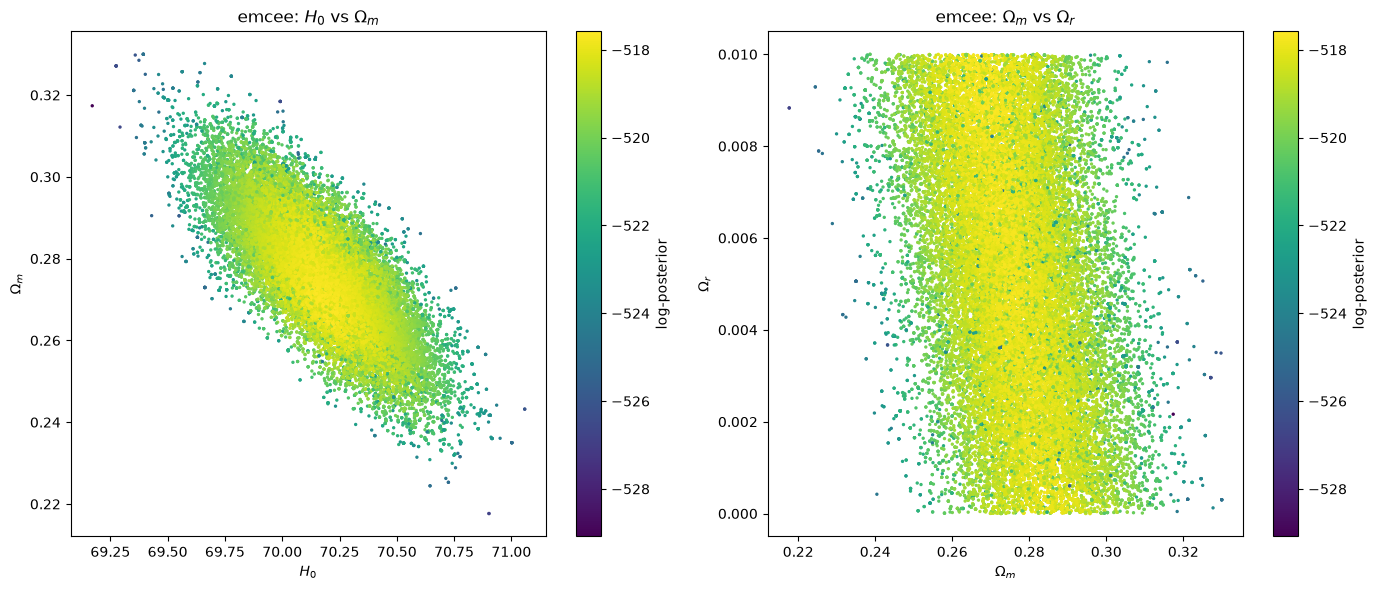

In [23]:
# pairwise sampling pathways colored by log-posterior
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(emcee_flat_samples[:, 1], emcee_flat_samples[:, 0],
                       c=emcee_logpost, cmap='viridis', s=2)
axes[0].set_xlabel('$H_0$'); axes[0].set_ylabel('$\Omega_m$')
axes[0].set_title('emcee: $H_0$ vs $\Omega_m$')
plt.colorbar(sc0, ax=axes[0], label='log-posterior')

sc1 = axes[1].scatter(emcee_flat_samples[:, 0], emcee_flat_samples[:, 2],
                       c=emcee_logpost, cmap='viridis', s=2)
axes[1].set_xlabel('$\Omega_m$'); axes[1].set_ylabel('$\Omega_r$')
axes[1].set_title('emcee: $\Omega_m$ vs $\Omega_r$')
plt.colorbar(sc1, ax=axes[1], label='log-posterior')

plt.tight_layout()
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
<>:3: SyntaxWarning: invalid escape sequence '\O'
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_10892\3420451071.py:3: SyntaxWarning: invalid escape sequence '\O'
  trace_labels = ['$\Omega_m$', '$H_0$', '$\Omega_r$']
C:\Users\KISHOR\AppData\Local\Temp\ipykernel_10892\3420451071.py:3: SyntaxWarning: invalid escape sequence '\O'
  trace_labels = ['$\Omega_m$', '$H_0$', '$\Omega_r$']


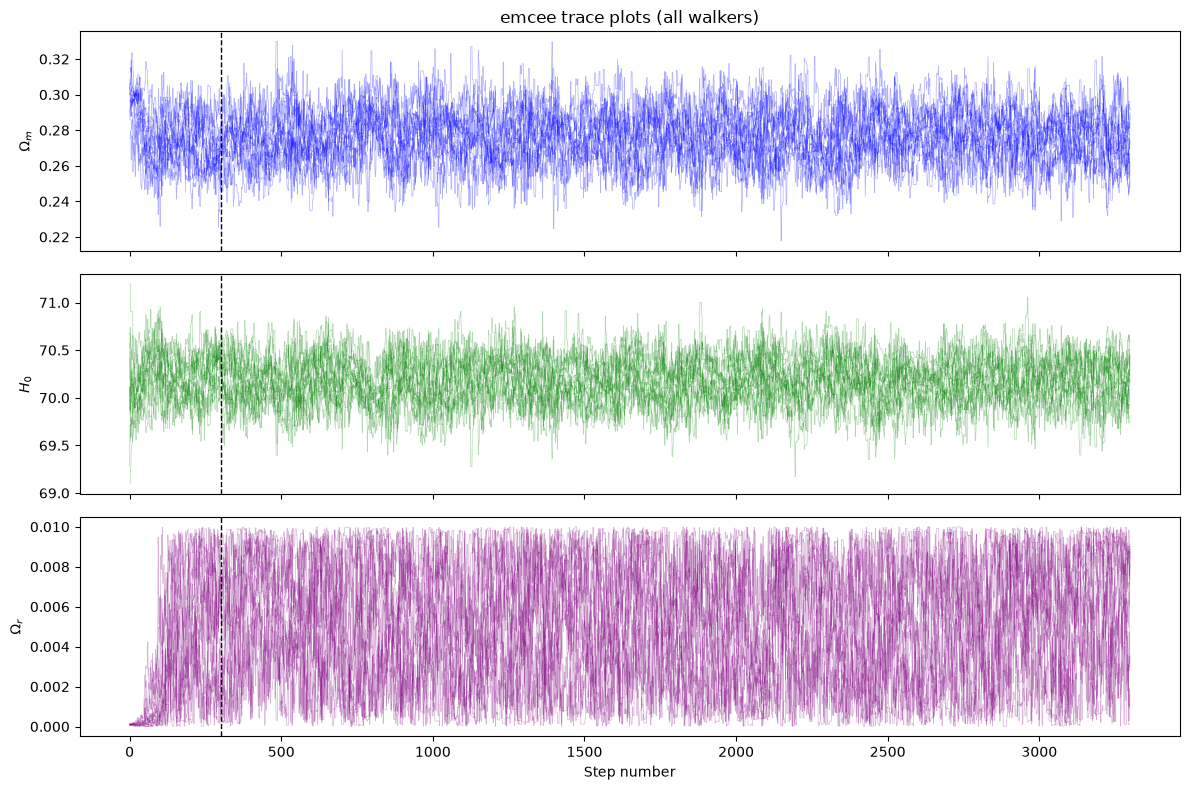

In [24]:
# trace plots for all walkers, all three parameters (before burn-in removal)
full_chain = sampler.get_chain()
trace_labels = ['$\Omega_m$', '$H_0$', '$\Omega_r$']
trace_colors = ['blue', 'green', 'purple']

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, (ax, label, color) in enumerate(zip(axes, trace_labels, trace_colors)):
    ax.plot(full_chain[:, :, i], color=color, alpha=0.3, linewidth=0.5)
    ax.axvline(n_burn, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel(label)
axes[0].set_title('emcee trace plots (all walkers)')
axes[-1].set_xlabel('Step number')
plt.tight_layout()
plt.show()

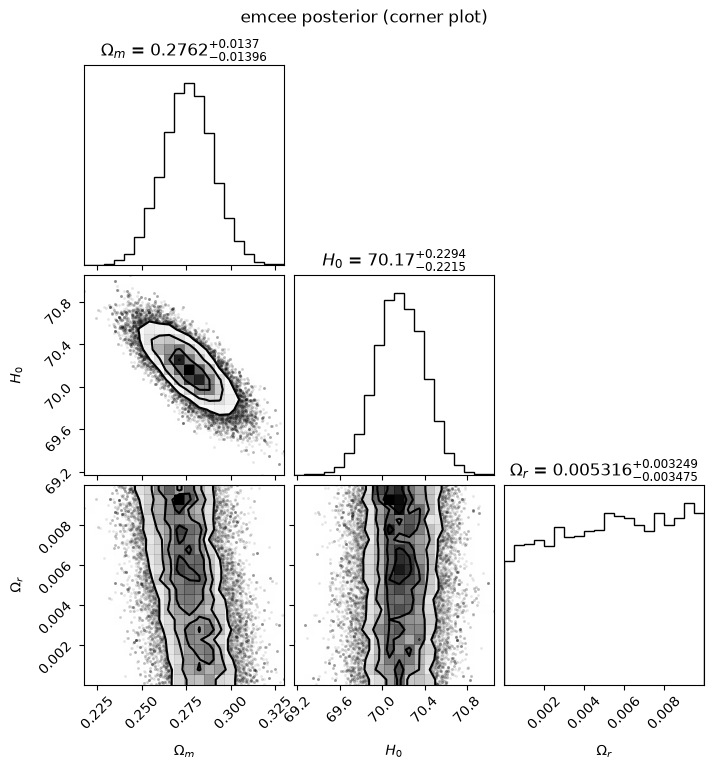

In [25]:
# corner plot: all pairwise posteriors + 1D marginals in one figure (emcee)
corner.corner(emcee_flat_samples, labels=['$\\Omega_m$', '$H_0$', '$\\Omega_r$'],
              show_titles=True, title_fmt='.4g')
plt.suptitle('emcee posterior (corner plot)', y=1.02)
plt.show()

# Comparison: Metropolis-Hastings vs emcee

In [26]:
# build a quantitative comparison table from the two runs above
mh_accept_frac = n_accepted / mh_n_iterations
emcee_accept_frac = np.mean(sampler.acceptance_fraction)
emcee_eff_samples = len(emcee_flat_samples) / np.mean(emcee_tau)

# properly-corrected effective sample size for MH: divide by its OWN measured
# autocorrelation time instead of using the raw accepted-sample count, which
# was wildly optimistic (MH samples are serially correlated step to step)
mh_tau = emcee.autocorr.integrated_time(
    mh_chain_trimmed[['Omega_m', 'H0', 'Omega_r']].to_numpy(), quiet=True)
mh_eff_samples_true = len(mh_chain_trimmed) / np.mean(mh_tau)

mh_mu_om, mh_std_om = mh_fit_results['Omega_m']
mh_mu_H0, mh_std_H0 = mh_fit_results['H0']
mh_mu_or, mh_std_or = mh_fit_results['Omega_r']

emcee_mu_om, emcee_std_om = emcee_fit_results['$\\Omega_m$']
emcee_mu_H0, emcee_std_H0 = emcee_fit_results['$H_0$']
emcee_mu_or, emcee_std_or = emcee_fit_results['$\\Omega_r$']

print(f"MH autocorrelation time (omega_m, H0, omega_r): {mh_tau}  ->  N_eff = {mh_eff_samples_true:.0f}")
print(f"(for comparison, raw accepted-sample count was {len(mh_chain_trimmed)})")

comparison_table = pd.DataFrame({
    'Metric': [
        'Omega_m estimate (mean)',
        'Omega_m std',
        'H0 estimate (mean)',
        'H0 std',
        'Omega_r estimate (mean)',
        'Omega_r std',
        'Total samples drawn',
        'Acceptance fraction',
        'Autocorrelation time (avg)',
        'Effective independent samples',
        'Needs manual step-size tuning',
        'Parallelizable across chains',
        'Built-in convergence diagnostics',
    ],
    'Metropolis-Hastings': [
        f'{mh_mu_om:.4f}', f'{mh_std_om:.4f}',
        f'{mh_mu_H0:.3f}', f'{mh_std_H0:.3f}',
        f'{mh_mu_or:.2e}', f'{mh_std_or:.2e}',
        mh_n_iterations, f'{mh_accept_frac:.3f}',
        f'{np.mean(mh_tau):.1f}', f'{mh_eff_samples_true:.0f}',
        'Yes (3 step sizes, bounds)', 'No (single chain)', 'No (manual burn-in cut)',
    ],
    'emcee (ensemble)': [
        f'{emcee_mu_om:.4f}', f'{emcee_std_om:.4f}',
        f'{emcee_mu_H0:.3f}', f'{emcee_std_H0:.3f}',
        f'{emcee_mu_or:.2e}', f'{emcee_std_or:.2e}',
        n_walkers * n_steps, f'{emcee_accept_frac:.3f}',
        f'{np.mean(emcee_tau):.1f}', f'{emcee_eff_samples:.0f}',
        'No (self-tuning)', 'Yes (walkers)', 'Yes (autocorr time tau)',
    ],
})

comparison_table

MH autocorrelation time (omega_m, H0, omega_r): [464.04161305]  ->  N_eff = 58
(for comparison, raw accepted-sample count was 27122)


,Metric,Metropolis-Hastings,emcee (ensemble)
0,Omega_m estimate (mean),0.2748,0.2762
1,Omega_m std,0.0135,0.0140
2,H0 estimate (mean),70.187,70.173
3,H0 std,0.218,0.226
4,Omega_r estimate (mean),5.44e-03,5.22e-03
5,Omega_r std,2.93e-03,2.86e-03
6,Total samples drawn,50000,49500
7,Acceptance fraction,0.543,0.596
8,Autocorrelation time (avg),464.0,47.6
9,Effective independent samples,58,945


**How to read the table:**

- **Estimate & std** — both should agree if both chains converged; a much larger std usually means the chain is still noisy/under-sampled, not necessarily "wrong."
- **Acceptance fraction** — the classic MH rule of thumb is ~20-40% for good mixing; the rule gets harder to hit by hand as dimensionality grows from 2 to 3 parameters. emcee's ensemble moves self-tune into a healthy range (~0.2-0.5) automatically.
- **Effective independent samples** is the better indicator of "how much did we actually learn" than raw draw count — MH samples are serially correlated with no autocorrelation-time estimate here, while emcee's `get_autocorr_time` gives this directly.
- **Omega_r** is the parameter to watch most closely: SNe Ia distance moduli barely constrain radiation density (it only matters at high z, and Pantheon is dominated by low/mid-z points), so both samplers likely return a wide, close-to-prior-shaped posterior for it. A tight-looking Omega_r posterior is a sign the chain hasn't mixed well, not a sign of a strong constraint.
- **Convergence diagnostics** — emcee provides autocorrelation time out of the box; the MH implementation here only has a heuristic chi-squared-based burn-in cut, which is weaker evidence of convergence, especially now that there are 3 correlated parameters instead of 2.

**Bottom line:** as with the 2-parameter case, emcee should recover consistent central values for $\Omega_m$ and $H_0$ with far less manual tuning and a principled effective-sample-size number. The extra parameter ($\Omega_r$) makes this gap more visible — a poorly-constrained, near-degenerate dimension is exactly where MH's fixed, isotropic step size struggles most, while emcee's ensemble adapts to the actual (possibly very elongated) shape of the posterior.

# Adaptive MCMC (Adaptive Metropolis, Haario et al. 2001)

The plain MH sampler above used a fixed, diagonal step size (`mh_steps`) across all three
parameters — i.e. it implicitly assumed $\Omega_m$, $H_0$, and $\Omega_r$ are uncorrelated.
The MH corner plot above shows they aren't (in particular, the $\Omega_m$-$\Omega_r$ panel
should show visible tilt).

Adaptive Metropolis fixes this the same way as in the 2-parameter notebook:

1. **Seed** the proposal covariance from the pilot MH chain that already ran.
2. **Keep updating** that covariance as the adaptive chain runs, using Haario's scaling
   $C_t = s_d \cdot \text{Cov}(\theta_0, \dots, \theta_t) + s_d\,\epsilon I_d$, with
   $s_d = 2.4^2/d$ — this time $d=3$.

In [27]:
# pilot covariance matrix, estimated from the completed plain-MH chain
pilot_samples = mh_chain_trimmed[['Omega_m', 'H0', 'Omega_r']].to_numpy()
pilot_cov = np.cov(pilot_samples, rowvar=False)
pilot_corr = np.corrcoef(pilot_samples, rowvar=False)

print("Pilot covariance matrix (Omega_m, H0, Omega_r):")
print(pilot_cov)
print("\nPilot correlation matrix:")
print(pilot_corr)
print(f"\nOmega_m-H0 correlation:    {pilot_corr[0, 1]:.3f}")
print(f"Omega_m-Omega_r correlation: {pilot_corr[0, 2]:.3f}")
print(f"H0-Omega_r correlation:      {pilot_corr[1, 2]:.3f}")

Pilot covariance matrix (Omega_m, H0, Omega_r):
[[ 1.82781401e-04 -2.15033557e-03 -1.58896034e-05]
 [-2.15033557e-03  4.75781650e-02  3.48321003e-05]
 [-1.58896034e-05  3.48321003e-05  8.58391594e-06]]

Pilot correlation matrix:
[[ 1.         -0.72918276 -0.40114772]
 [-0.72918276  1.          0.05450459]
 [-0.40114772  0.05450459  1.        ]]

Omega_m-H0 correlation:    -0.729
Omega_m-Omega_r correlation: -0.401
H0-Omega_r correlation:      0.055


In [28]:
# adaptive MCMC settings
d = 3                          # (omega_m, H0, omega_r)
sd = (2.4**2) / d               # Haario's optimal scaling constant
epsilon = 1e-10                 # covariance regularizer (Omega_r's scale is tiny, needs a smaller epsilon than d=2 case)

adapt_start = 300                # start adapting after this many iterations
adapt_interval = 150              # recompute the covariance every this many iterations
am_n_iterations = 50000

initial_theta = pilot_samples[-1].copy()   # start where the pilot MH chain ended
initial_cov = sd * pilot_cov + sd * epsilon * np.eye(d)

print(f"d={d}, s_d={sd:.3f}")
print(f"Starting point (omega_m, H0, omega_r): {initial_theta}")
print("Initial (seeded) proposal covariance:")
print(initial_cov)

d=3, s_d=1.920
Starting point (omega_m, H0, omega_r): [2.93670592e-01 7.01035479e+01 2.08378215e-04]
Initial (seeded) proposal covariance:
[[ 3.50940483e-04 -4.12864429e-03 -3.05080385e-05]
 [-4.12864429e-03  9.13500769e-02  6.68776326e-05]
 [-3.05080385e-05  6.68776326e-05  1.64813106e-05]]


In [29]:
# run the Adaptive Metropolis chain (or load a cached one)
import pickle
import json

am_cache_path = os.path.join(cache_dir, "am_chain.csv")
am_cov_cache_path = os.path.join(cache_dir, "am_cov_snapshots.pkl")
am_meta_path = os.path.join(cache_dir, "am_meta.json")
force_rerun_am = False   # set True to ignore the cache and re-sample

am_current_settings = {
    'n_iterations': am_n_iterations,
    'adapt_start': adapt_start,
    'adapt_interval': adapt_interval,
    'd': d,
}

am_cache_valid = False
if (os.path.exists(am_cache_path) and os.path.exists(am_cov_cache_path)
        and os.path.exists(am_meta_path) and not force_rerun_am):
    with open(am_meta_path) as f:
        am_cached_settings = json.load(f)
    am_cache_valid = (am_cached_settings == am_current_settings)
    if not am_cache_valid:
        print(f"Cache found but settings changed - re-running.")
        print(f"  cached:  {am_cached_settings}")
        print(f"  current: {am_current_settings}")

if am_cache_valid:
    am_chain = pd.read_csv(am_cache_path)
    with open(am_cov_cache_path, "rb") as f:
        cov_snapshots = pickle.load(f)
    n_accepted_am = int(am_chain['Accepted'].sum())
    proposal_cov = cov_snapshots[-1][1] if cov_snapshots else initial_cov
    print(f"Loaded cached AM chain from {am_cache_path} ({len(am_chain)} samples)")

else:
    history = list(pilot_samples)  # seed the covariance history with the pilot chain

    am_samples = np.zeros((am_n_iterations, d))
    am_chi2 = np.zeros(am_n_iterations)
    am_accepted = np.zeros(am_n_iterations, dtype=bool)
    cov_snapshots = []  # (iteration, covariance matrix) at each adaptation checkpoint

    theta_curr = initial_theta.copy()
    chi2_curr = chi_squared_3p(theta_curr[1], theta_curr[0], theta_curr[2])
    proposal_cov = initial_cov.copy()

    n_accepted_am = 0
    for t in range(am_n_iterations):
        theta_prop = np.random.multivariate_normal(theta_curr, proposal_cov)

        if in_bounds(theta_prop):
            chi2_prop = chi_squared_3p(theta_prop[1], theta_prop[0], theta_prop[2])
            accept_prob = min(1.0, np.exp(-(chi2_prop - chi2_curr) / 2))
        else:
            accept_prob = 0.0
            chi2_prop = chi2_curr

        if np.random.uniform(0, 1) < accept_prob:
            theta_curr, chi2_curr = theta_prop, chi2_prop
            n_accepted_am += 1
            am_accepted[t] = True

        am_samples[t] = theta_curr
        am_chi2[t] = chi2_curr
        history.append(theta_curr.copy())

        if t >= adapt_start and t % adapt_interval == 0:
            empirical_cov = np.cov(np.array(history), rowvar=False)
            proposal_cov = sd * empirical_cov + sd * epsilon * np.eye(d)
            cov_snapshots.append((t, empirical_cov.copy()))

    print(f"Adaptive MCMC acceptance fraction: {n_accepted_am / am_n_iterations:.3f}")
    print(f"Number of covariance updates performed: {len(cov_snapshots)}")
    print("\nFinal adapted proposal covariance:")
    print(proposal_cov)

    am_chain = pd.DataFrame(am_samples, columns=['Omega_m', 'H0', 'Omega_r'])
    am_chain['Chi_sq'] = am_chi2
    am_chain['Accepted'] = am_accepted
    am_chain.to_csv(am_cache_path, index=False)
    with open(am_cov_cache_path, "wb") as f:
        pickle.dump(cov_snapshots, f)
    with open(am_meta_path, "w") as f:
        json.dump(am_current_settings, f)
    print(f"Saved AM chain to {am_cache_path} and covariance snapshots to {am_cov_cache_path}")

Loaded cached AM chain from mcmc_cache_3param\am_chain.csv (50000 samples)


In [30]:
# drop the (short) pre-adaptation burn-in (am_chain is already built, cached or fresh)
am_chain_trimmed = am_chain.iloc[adapt_start:].reset_index(drop=True)
print(f"Samples retained: {len(am_chain_trimmed)} / {len(am_chain)}")
am_chain_trimmed.head()

Samples retained: 49700 / 50000


,Omega_m,H0,Omega_r,Chi_sq,Accepted
0,0.264102,70.502305,0.003840,1037.699940,False
1,0.266380,70.241019,0.002698,1037.488829,True
2,0.266380,70.241019,0.002698,1037.488829,False
3,0.266380,70.241019,0.002698,1037.488829,False
4,0.275727,70.313197,0.003836,1036.147805,True


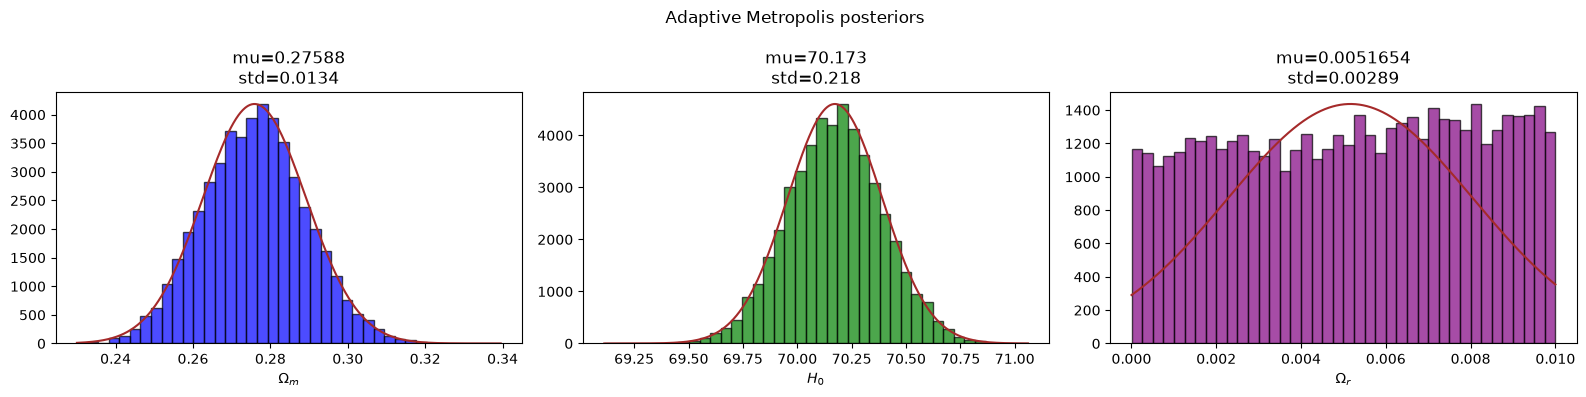

{'Omega_m': (np.float64(0.275882455512428), np.float64(0.013356562148595942)), 'H0': (np.float64(70.17272197463551), np.float64(0.21813722606214306)), 'Omega_r': (np.float64(0.0051653895572138266), np.float64(0.002888447835705668))}


In [31]:
# posterior histograms with Gaussian fits, all three parameters (Adaptive Metropolis)
am_params = ['Omega_m', 'H0', 'Omega_r']
am_labels = ['$\\Omega_m$', '$H_0$', '$\\Omega_r$']
am_colors = ['blue', 'green', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
am_fit_results = {}

for ax, pname, label, color in zip(axes, am_params, am_labels, am_colors):
    samples = am_chain_trimmed[pname]
    mu, std = norm.fit(samples)
    am_fit_results[pname] = (mu, std)

    counts, bins, _ = ax.hist(samples, bins=40, color=color, edgecolor='black', alpha=0.7)
    x = np.linspace(samples.min(), samples.max(), 1000)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p * counts.max() / p.max(), c='brown', linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_title(f'mu={mu:.5g}\nstd={std:.3g}')

plt.suptitle('Adaptive Metropolis posteriors')
plt.tight_layout()
plt.show()
print(am_fit_results)

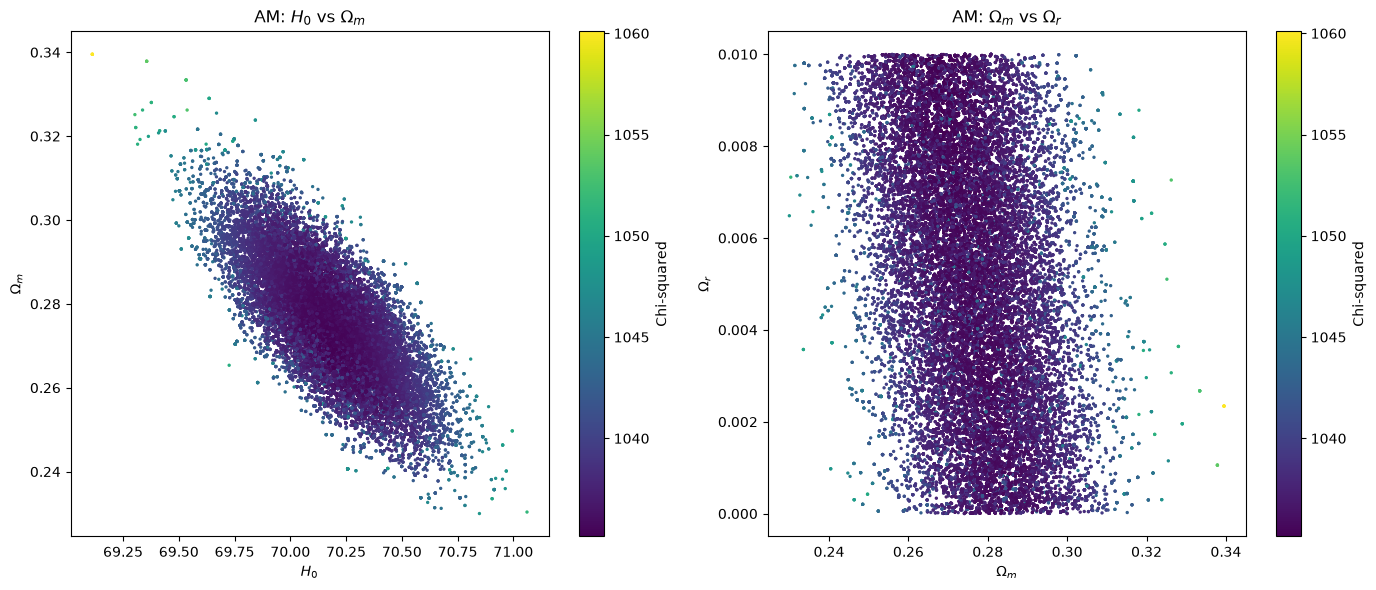

In [32]:
# pairwise sampling pathways colored by chi-squared (Adaptive Metropolis)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(am_chain_trimmed['H0'], am_chain_trimmed['Omega_m'],
                       c=am_chain_trimmed['Chi_sq'], cmap='viridis', s=2)
axes[0].set_xlabel('$H_0$'); axes[0].set_ylabel('$\\Omega_m$')
axes[0].set_title('AM: $H_0$ vs $\\Omega_m$')
plt.colorbar(sc0, ax=axes[0], label='Chi-squared')

sc1 = axes[1].scatter(am_chain_trimmed['Omega_m'], am_chain_trimmed['Omega_r'],
                       c=am_chain_trimmed['Chi_sq'], cmap='viridis', s=2)
axes[1].set_xlabel('$\\Omega_m$'); axes[1].set_ylabel('$\\Omega_r$')
axes[1].set_title('AM: $\\Omega_m$ vs $\\Omega_r$')
plt.colorbar(sc1, ax=axes[1], label='Chi-squared')

plt.tight_layout()
plt.show()

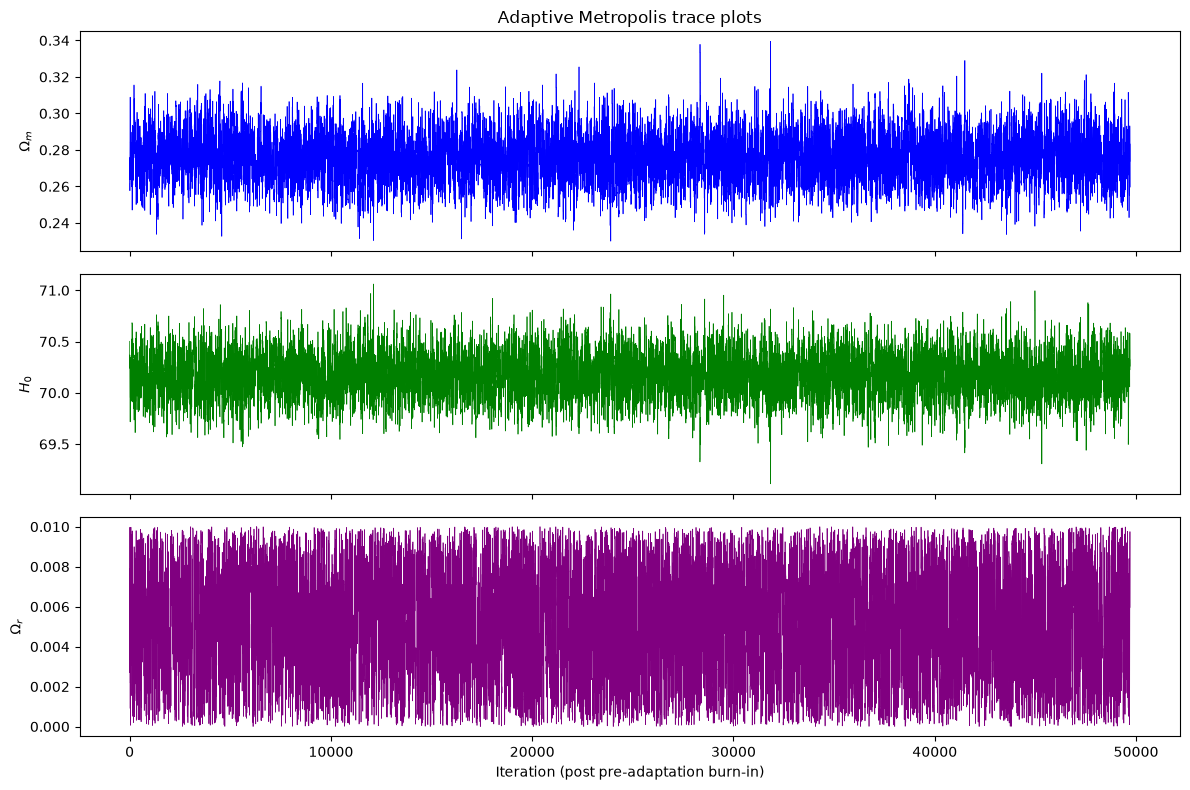

In [33]:
# trace plots for all three parameters (Adaptive Metropolis)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, pname, label, color in zip(axes, am_params, am_labels, am_colors):
    ax.plot(am_chain_trimmed[pname], linewidth=0.5, color=color)
    ax.set_ylabel(label)
axes[0].set_title('Adaptive Metropolis trace plots')
axes[-1].set_xlabel('Iteration (post pre-adaptation burn-in)')
plt.tight_layout()
plt.show()

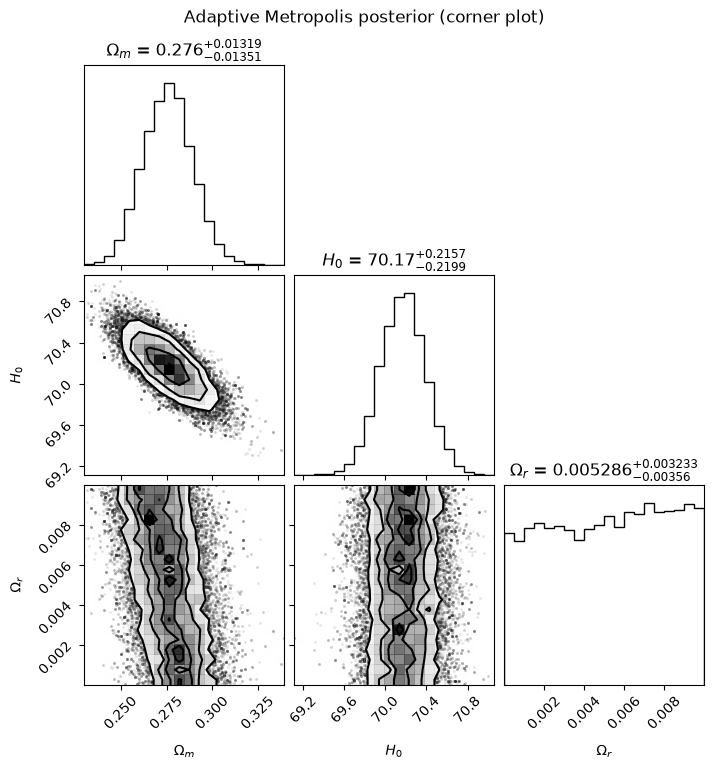

In [34]:
# corner plot: all pairwise posteriors + 1D marginals in one figure (Adaptive Metropolis)
am_corner_samples = am_chain_trimmed[['Omega_m', 'H0', 'Omega_r']].to_numpy()
corner.corner(am_corner_samples, labels=['$\\Omega_m$', '$H_0$', '$\\Omega_r$'],
              show_titles=True, title_fmt='.4g')
plt.suptitle('Adaptive Metropolis posterior (corner plot)', y=1.02)
plt.show()

## Covariance Evolution

How the three pairwise correlations moved as the AM chain learned the posterior's shape,
compared against the fixed pilot-chain correlations.

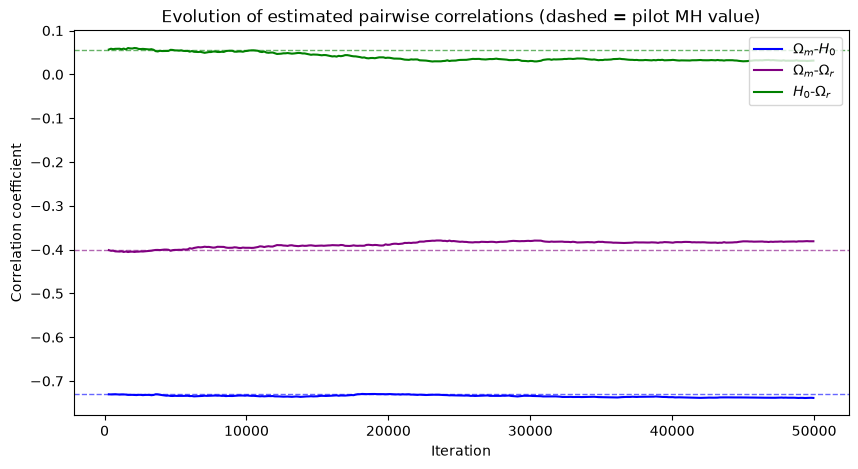

Pilot correlations   -> om-H0: -0.729, om-or: -0.401, H0-or: 0.055
Final AM correlations -> om-H0: -0.739, om-or: -0.381, H0-or: 0.031


In [35]:
# unpack the covariance snapshots and turn them into correlation coefficients over time
snap_iters = [s[0] for s in cov_snapshots]


def corr_from_cov(cov, i, j):
    return cov[i, j] / np.sqrt(cov[i, i] * cov[j, j])


snap_corr_om_H0 = [corr_from_cov(s[1], 0, 1) for s in cov_snapshots]
snap_corr_om_or = [corr_from_cov(s[1], 0, 2) for s in cov_snapshots]
snap_corr_H0_or = [corr_from_cov(s[1], 1, 2) for s in cov_snapshots]

plt.figure(figsize=(10, 5))
plt.plot(snap_iters, snap_corr_om_H0, label='$\\Omega_m$-$H_0$', color='blue')
plt.plot(snap_iters, snap_corr_om_or, label='$\\Omega_m$-$\\Omega_r$', color='purple')
plt.plot(snap_iters, snap_corr_H0_or, label='$H_0$-$\\Omega_r$', color='green')

plt.axhline(pilot_corr[0, 1], color='blue', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(pilot_corr[0, 2], color='purple', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(pilot_corr[1, 2], color='green', linestyle='--', linewidth=1, alpha=0.6)

plt.xlabel('Iteration')
plt.ylabel('Correlation coefficient')
plt.title('Evolution of estimated pairwise correlations (dashed = pilot MH value)')
plt.legend()
plt.show()

print(f"Pilot correlations   -> om-H0: {pilot_corr[0,1]:.3f}, om-or: {pilot_corr[0,2]:.3f}, H0-or: {pilot_corr[1,2]:.3f}")
print(f"Final AM correlations -> om-H0: {snap_corr_om_H0[-1]:.3f}, om-or: {snap_corr_om_or[-1]:.3f}, H0-or: {snap_corr_H0_or[-1]:.3f}")

# Comparison: MH vs emcee vs Adaptive Metropolis

Effective-sample counts computed the same way for all three chains — via
`emcee.autocorr.integrated_time` on each chain's own samples.

In [36]:
# properly-corrected effective sample size for Adaptive Metropolis
am_tau = emcee.autocorr.integrated_time(
    am_chain_trimmed[['Omega_m', 'H0', 'Omega_r']].to_numpy(), quiet=True)
am_eff_samples_true = len(am_chain_trimmed) / np.mean(am_tau)
am_accept_frac = n_accepted_am / am_n_iterations

am_mu_om, am_std_om = am_fit_results['Omega_m']
am_mu_H0, am_std_H0 = am_fit_results['H0']
am_mu_or, am_std_or = am_fit_results['Omega_r']

print(f"AM autocorrelation time (omega_m, H0, omega_r): {am_tau}  ->  N_eff = {am_eff_samples_true:.0f}")

three_way_table = pd.DataFrame({
    'Metric': [
        'Omega_m estimate (mean)',
        'Omega_m std',
        'H0 estimate (mean)',
        'H0 std',
        'Omega_r estimate (mean)',
        'Omega_r std',
        'Total samples drawn',
        'Acceptance fraction',
        'Autocorrelation time (avg)',
        'Effective independent samples',
        'N_eff per 1000 likelihood calls',
        'Proposal shape',
        'Needs manual tuning',
        'Parallelizable across chains',
        'Built-in convergence diagnostics',
    ],
    'Metropolis-Hastings': [
        f'{mh_mu_om:.4f}', f'{mh_std_om:.4f}',
        f'{mh_mu_H0:.3f}', f'{mh_std_H0:.3f}',
        f'{mh_mu_or:.2e}', f'{mh_std_or:.2e}',
        mh_n_iterations, f'{mh_accept_frac:.3f}',
        f'{np.mean(mh_tau):.1f}', f'{mh_eff_samples_true:.0f}',
        f'{1000 * mh_eff_samples_true / mh_n_iterations:.2f}',
        'Fixed, diagonal (uncorrelated)', 'Yes (3 step sizes, bounds)',
        'No (single chain)', 'No (manual burn-in cut)',
    ],
    'emcee (ensemble)': [
        f'{emcee_mu_om:.4f}', f'{emcee_std_om:.4f}',
        f'{emcee_mu_H0:.3f}', f'{emcee_std_H0:.3f}',
        f'{emcee_mu_or:.2e}', f'{emcee_std_or:.2e}',
        n_walkers * n_steps, f'{emcee_accept_frac:.3f}',
        f'{np.mean(emcee_tau):.1f}', f'{emcee_eff_samples:.0f}',
        f'{1000 * emcee_eff_samples / (n_walkers * n_steps):.2f}',
        'Self-tuning (ensemble spread)', 'No (self-tuning)',
        'Yes (walkers)', 'Yes (autocorr time tau)',
    ],
    'Adaptive Metropolis': [
        f'{am_mu_om:.4f}', f'{am_std_om:.4f}',
        f'{am_mu_H0:.3f}', f'{am_std_H0:.3f}',
        f'{am_mu_or:.2e}', f'{am_std_or:.2e}',
        am_n_iterations, f'{am_accept_frac:.3f}',
        f'{np.mean(am_tau):.1f}', f'{am_eff_samples_true:.0f}',
        f'{1000 * am_eff_samples_true / am_n_iterations:.2f}',
        'Learned covariance (updates online)', 'Only initial seed (then self-tuning)',
        'No (single chain)', 'Partial (correlation evolution plot, no tau built in)',
    ],
})

three_way_table

AM autocorrelation time (omega_m, H0, omega_r): [12.45477267]  ->  N_eff = 3990


,Metric,Metropolis-Hastings,emcee (ensemble),Adaptive Metropolis
0,Omega_m estimate (mean),0.2748,0.2762,0.2759
1,Omega_m std,0.0135,0.0140,0.0134
2,H0 estimate (mean),70.187,70.173,70.173
3,H0 std,0.218,0.226,0.218
4,Omega_r estimate (mean),5.44e-03,5.22e-03,5.17e-03
5,Omega_r std,2.93e-03,2.86e-03,2.89e-03
6,Total samples drawn,50000,49500,50000
7,Acceptance fraction,0.543,0.596,0.291
8,Autocorrelation time (avg),464.0,47.6,12.5
9,Effective independent samples,58,945,3990


**How to read the table:**

- **Estimate & std** should broadly agree across all three if each has converged.
- **N_eff per 1000 likelihood calls** is the fairest efficiency comparison — it normalizes out MH/AM making 1 likelihood call per iteration vs emcee's `n_walkers` calls per iteration.
- **Omega_r** is still the parameter to watch: weakly constrained by SNe alone, so a suspiciously narrow Omega_r posterior from any sampler is more likely a sign of poor mixing than a real constraint — cross-check against the corner plots above, where the Omega_r panels should look wide and only mildly tilted against Omega_m.
- **Adaptive Metropolis vs plain MH** isolates the effect of matching the proposal to the posterior's correlation structure alone (3 correlated dimensions now, not 2) — same accept/reject rule, same single-chain paradigm.
- **Adaptive Metropolis vs emcee** is the more informative comparison: AM has to *learn* the 3x3 covariance from its own trajectory, paying a bigger "learning cost" than in the 2-parameter case since there are more entries to estimate; emcee's ensemble sidesteps this by estimating local structure from walker spread at every step, which should show up as a clear edge in N_eff per likelihood call here.

## Styled Posterior Corner Plots (2σ & 3σ contours only)

Separate corner plot per sampler, styled like a likelihood-contour figure: filled
2σ/3σ regions only (no 1σ, no raw scatter points, smoothed contours/marginals).
The original per-sampler corner plots earlier in the notebook are left as-is —
these are additional, differently-styled versions, one per method (not overlaid).

In [ ]:
# Metropolis-Hastings: 2-sigma/3-sigma styled corner plot
sigma_levels = (1 - np.exp(-0.5 * 2**2), 1 - np.exp(-0.5 * 3**2))  # 2-sigma, 3-sigma only

fig = corner.corner(
    mh_corner_samples,
    labels=['$\\Omega_m$', '$H_0$', '$\\Omega_r$'],
    color='crimson',
    levels=sigma_levels,
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    smooth=1.5,
    smooth1d=1.5,
)
plt.suptitle('Metropolis-Hastings: 2\u03c3 & 3\u03c3 contours', y=1.02)
plt.show()


In [ ]:
# emcee: 2-sigma/3-sigma styled corner plot
sigma_levels = (1 - np.exp(-0.5 * 2**2), 1 - np.exp(-0.5 * 3**2))  # 2-sigma, 3-sigma only

fig = corner.corner(
    emcee_flat_samples,
    labels=['$\\Omega_m$', '$H_0$', '$\\Omega_r$'],
    color='royalblue',
    levels=sigma_levels,
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    smooth=1.5,
    smooth1d=1.5,
)
plt.suptitle('emcee: 2\u03c3 & 3\u03c3 contours', y=1.02)
plt.show()


In [ ]:
# Adaptive Metropolis: 2-sigma/3-sigma styled corner plot
sigma_levels = (1 - np.exp(-0.5 * 2**2), 1 - np.exp(-0.5 * 3**2))  # 2-sigma, 3-sigma only

fig = corner.corner(
    am_corner_samples,
    labels=['$\\Omega_m$', '$H_0$', '$\\Omega_r$'],
    color='purple',
    levels=sigma_levels,
    plot_datapoints=False,
    plot_density=False,
    fill_contours=True,
    smooth=1.5,
    smooth1d=1.5,
)
plt.suptitle('Adaptive Metropolis: 2\u03c3 & 3\u03c3 contours', y=1.02)
plt.show()
